In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from src.preprocessing import compute_laps, data_cleaning, import_data, braking_zones, corner_detector
from src.kpi import lap_kpi,  braking_kpi, acceleration_pickup_point
from src.plotting import base_analysis_plot, trajectory_plot, braking_plot, braking_analysis, turning_plot
pd.set_option('future.no_silent_downcasting', True)

count    1.460700e+04
mean     5.000000e-02
std      3.414184e-14
min      5.000000e-02
25%      5.000000e-02
50%      5.000000e-02
75%      5.000000e-02
max      5.000000e-02
Name: Time, dtype: float64
Index(['Time', 'GPS Speed', 'GPS Nsat', 'GPS LatAcc', 'GPS LonAcc',
       'GPS Slope', 'GPS Heading', 'GPS Gyro', 'GPS Altitude',
       'GPS PosAccuracy', 'GPS SpdAccuracy', 'GPS Radius', 'GPS Latitude',
       'GPS Longitude', 'Logger Temperature', 'Water Temp', 'AccelerometerX',
       'AccelerometerY', 'AccelerometerZ', 'GyroX', 'GyroY', 'GyroZ',
       'Int Batt Voltage', 'RPM', 'Calculated Gear', 'Distance on GPS Speed',
       'Distance'],
      dtype='object')


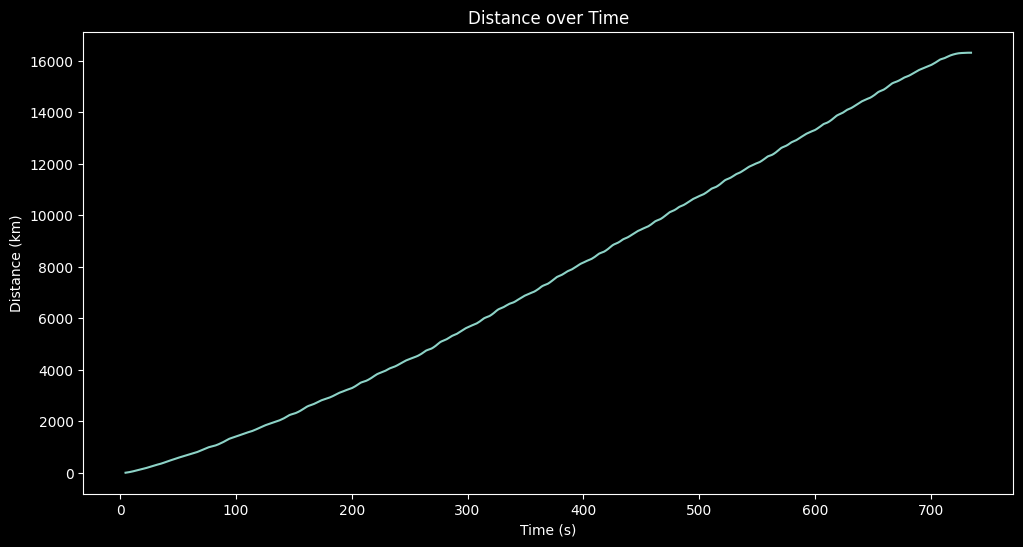

the total distance is  16303.690097222172


In [7]:
# Import excel file
df = import_data('data/telemetry.xlsx')

# Data cleaning
df = data_cleaning(df)

print(df.columns)
plt.figure(figsize=(12,6))                          # verification that distance is a monotonous curve
plt.plot (df['Time'], df ['Distance'])
plt.xlabel('Time (s)')
plt.ylabel('Distance (km)')
plt.title('Distance over Time')
plt.show()
print('the total distance is ', df['Distance'].iloc[-1])

# Lap times aquisition
To start with the data analysis it is fundamental to extract lap times from row data. Initially, a starting line is defined: each time the kart crosses it, a lap time will be stored. To identify line crossings, a boolean value tells if the coordinates (latitude and longitude) of the kart get within a certain tolerance from the starting line.
When lap times are defined, the best lap is chosen and it will be the object of the following analysis.

In [8]:
# laps computation
df = compute_laps(df)
lap_times = df.groupby('Lap_id')['Time'].agg(['min', 'max'])                # group by lap_id and define lap times
lap_times['Lap_time'] = lap_times['max'] - lap_times['min']
lap_times = lap_times.iloc[1:-1]
print (lap_times)
fastest_lap_idx = lap_times['Lap_time'].idxmin()
fastest_lap = lap_times['Lap_time'].min()
print (f"The best lap is: lap {fastest_lap_idx} = {fastest_lap:.2f}")

# Best lap definition
best_lap = df[df['Lap_id']== lap_times['Lap_time'].idxmin()].copy()

# KPI
kpi = lap_kpi(best_lap)
kpi


The number of lap is 14
           min     max  Lap_time
Lap_id                          
2         8.55   92.80     84.25
3        92.85  160.50     67.65
4       160.55  220.75     60.20
5       220.80  275.70     54.90
6       275.75  325.40     49.65
7       325.45  375.70     50.25
8       375.75  424.65     48.90
9       424.70  473.10     48.40
10      473.15  521.55     48.40
11      521.60  570.05     48.45
12      570.10  618.00     47.90
13      618.05  665.95     47.90
The best lap is: lap 12 = 47.90


{'Max speed [km/h]': np.float64(142.0),
 'Mean speed [km/h]': np.float64(94.2),
 'Max RPM': 15339,
 'Mean RPM': 12813}

# Best lap base analysis
Once the fastest lap is found, a base analysis consists in some plots, which show the evolution of some parameters during the lap. Some of these parameters are the speed, the engine speed, the longitudinal and lateral acceleration.

The speed trend is important to identify breaking points, corner speed and speed trap at the end of the straights.

The engine speed shows the effectiveness of gear shifts, potential over-rev zone and can be used to define the correct transmission ratios.

Longitudinal acceleration plots can be used to distinguish braking and traction points, while lateral acceleration plots show if cornering is smooth or dirt (if there are irregular peaks).



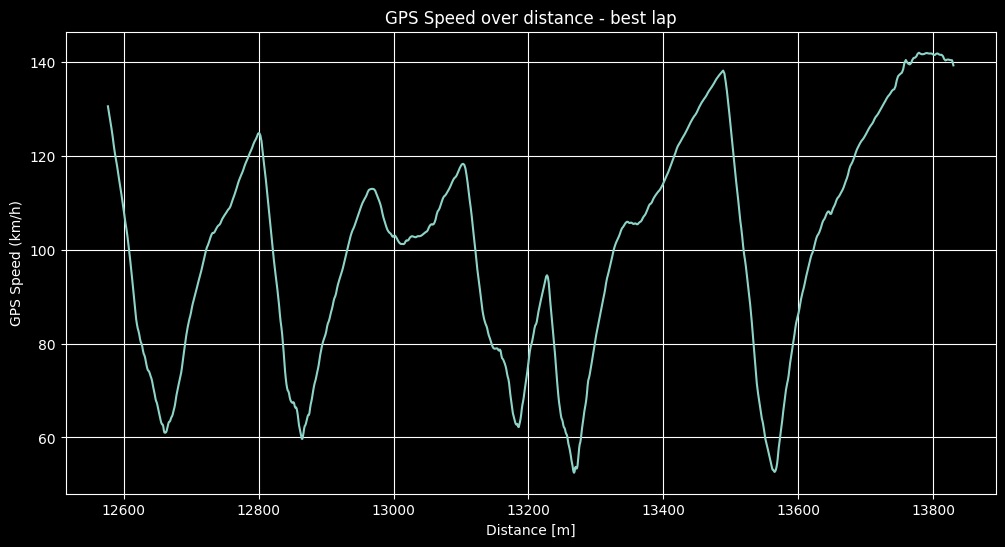

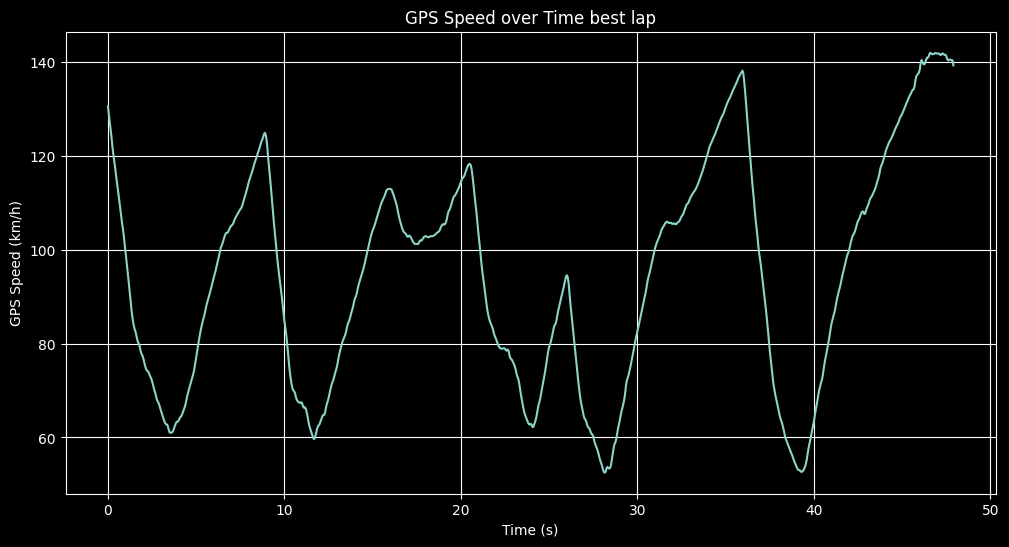

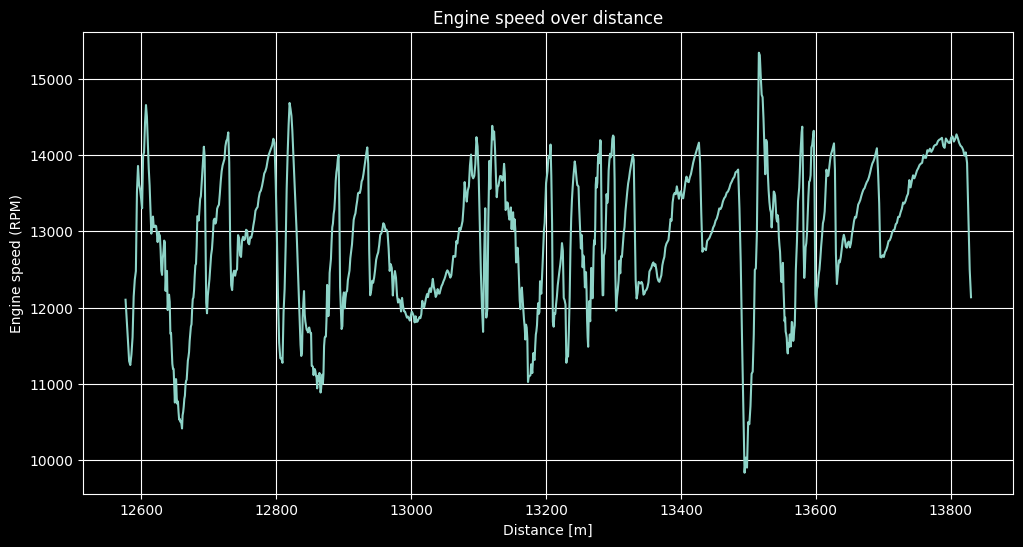

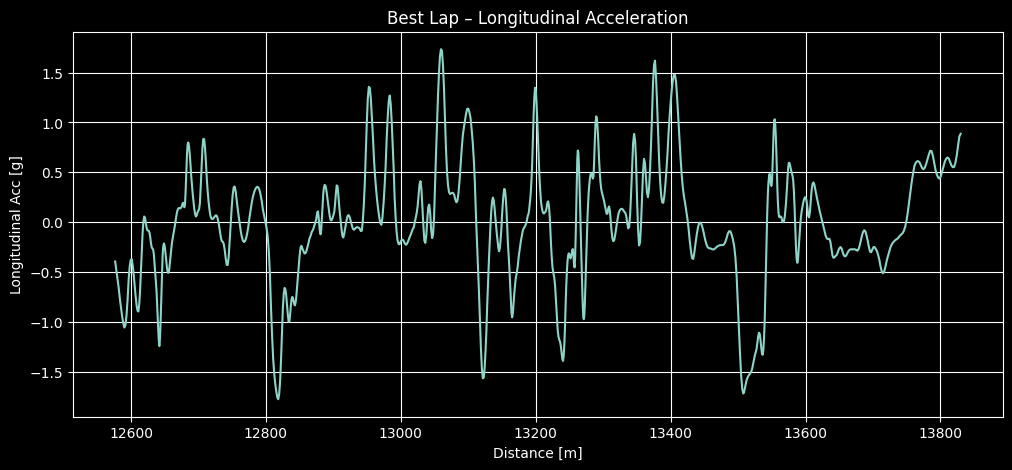

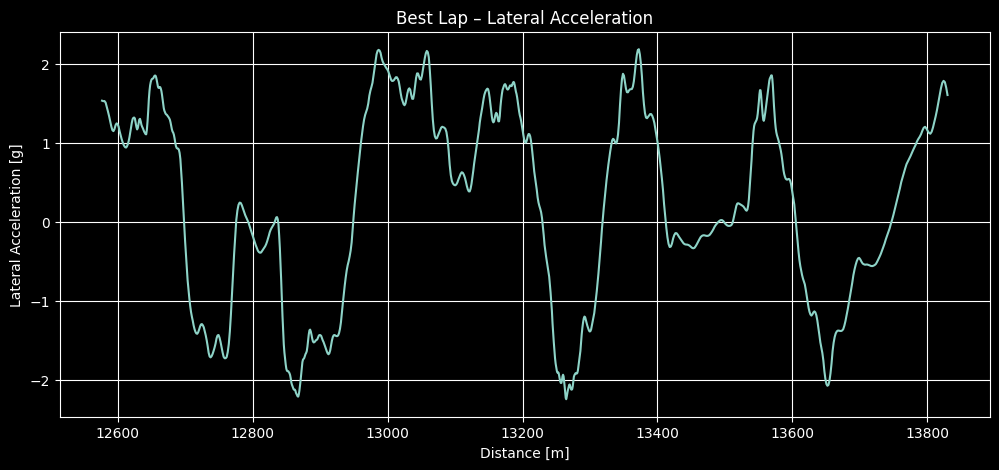

In [9]:

best_lap['t']= best_lap['Time'] - best_lap['Time'].iloc[0]              # define relative time
best_lap['s']= best_lap['Distance'] - best_lap['Distance'].iloc[0]      # define relative distance

base_analysis_plot(best_lap)

# Trajectory plot
The following section has the aim to represent graphically the evolution of the velocity, the engine speed and the accelerations.

In the velocity plot the faster sectors of the track are highlighted in red, while blue represents the slower sections. The highest speed is reached at the end of the main straight and at the end of the opposite straight approaching the last hairpin, which is the slowest part of the circuit.

The engine speed plot is helpful to identify the gear selected in every corner, knowing that the kart is endowed with a 6-speed gearbox. Blue regions represent downshifts, while a red region followed by a green one defines an upshift. It can be noted that the working range during an acceleration is between 12,000 and 15,000 RPM.

Longitudinal accelerations represent braking and acceleration sections. The blue color identifies braking zones, while the red color is used for the accelerations. A deeper analysis of breaking zones will follow in the next section.

To evaluate the regions where tires are more under stress the lateral acceleration plot is the best solution. In left corners, accelerations are positive (red), while in right corners, accelerations are negative (blue), according to the Mychron reference frame. The color intensity defines the magnitude of the acceleration. We can identify a correlation between faster corners and stronger lateral accelerations.

A deeper analysis of these plots is provided in the following sections.

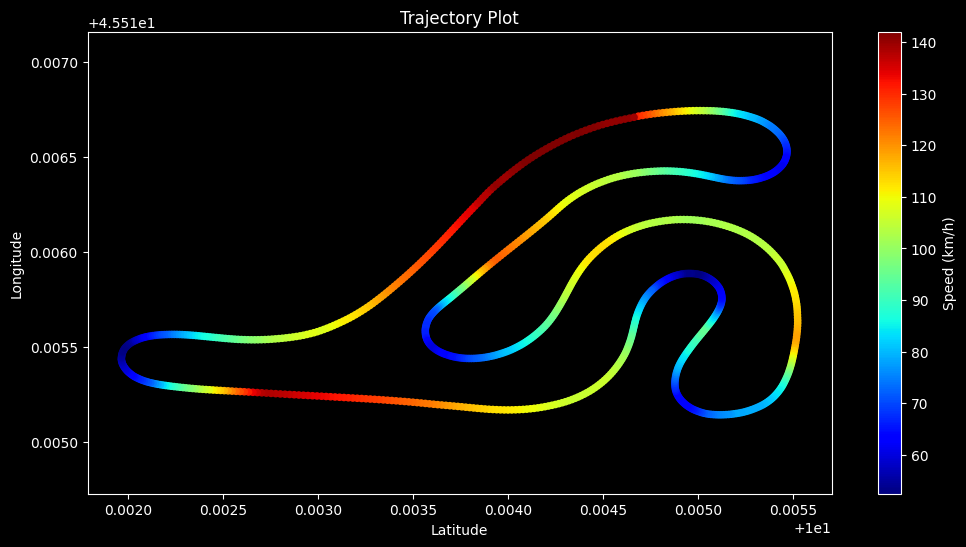

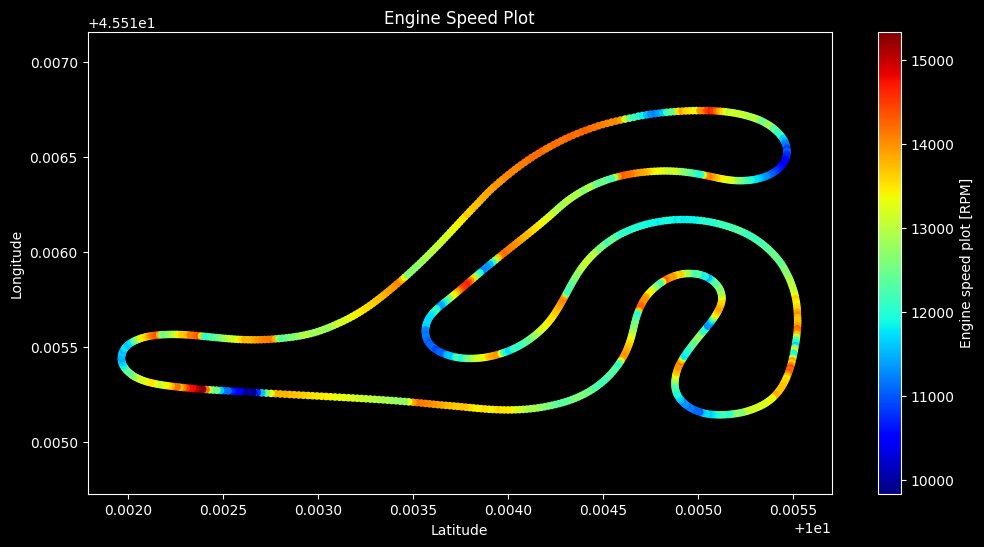

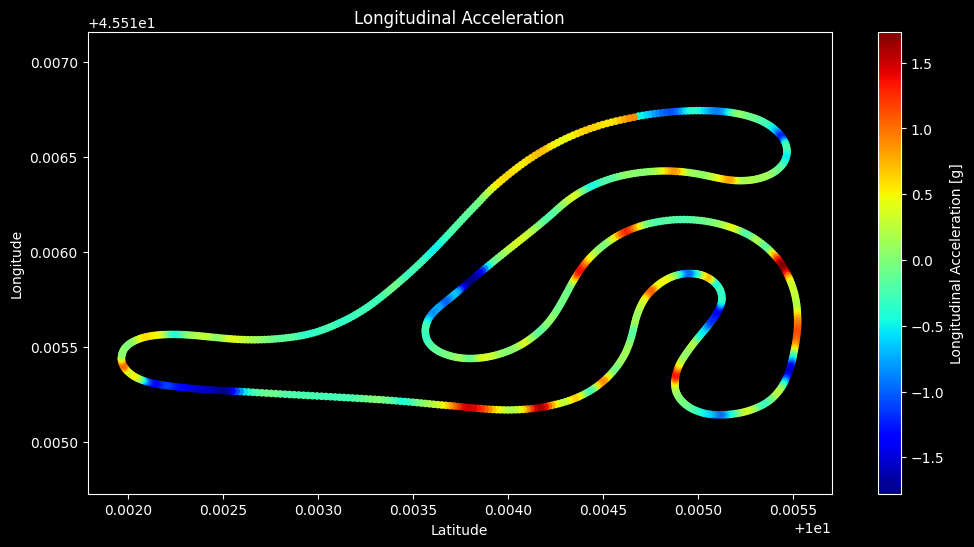

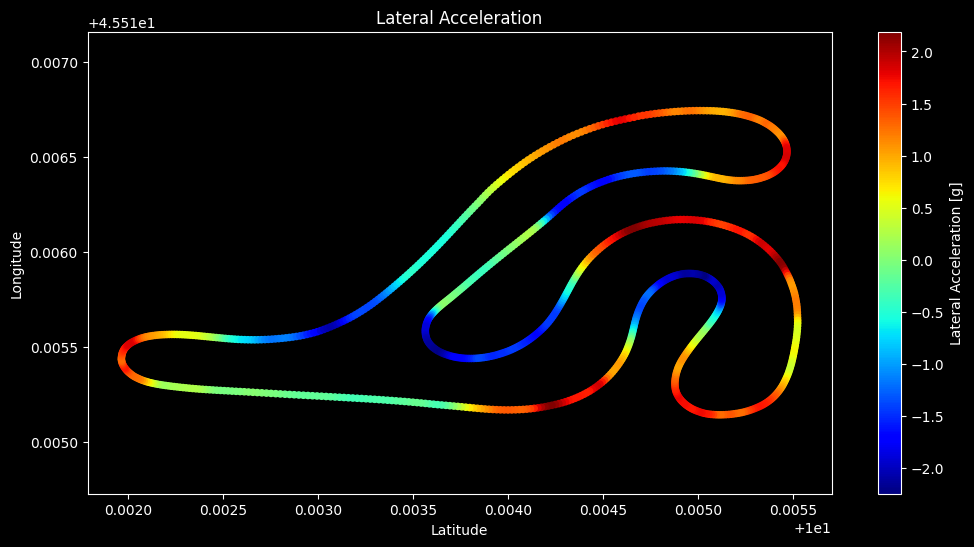

In [10]:
trajectory_plot(best_lap)


# Braking zone analysis

## Braking events detection
This section will analyze braking zones. To identify a breaking zone a strong longitudinal deceleration should be detected. A threshold level of 1 g of deceleration is chosen according to data. 6 breaking events are detected. The 1st and the 2nd are considered as two separated braking manoeuvres, even though they refer to the same corner. This is probably due to the fact that, approaching the first corner the driver start hard braking to reduce the speed in the first part of the corner then release slightly the pedal. Then the corner suddenly becomes sharper and the kart slow down again.

Then, for each braking zone the average and the maximum deceleration, the entry speed, the minimum speed and the braking length are calculated.
From Data it is evident that the strongest decelerations are reached in the 3rd (-1.77 g) and the 6th braking events (-1.71 g). The last one is also the longest (37 m) and that with the slowest speed (70 km/h). It is a strong braking after a long straight before an hairpin, so it is fundamental to brake hard to reduce the speed to provide a correct corner entry.

After the 3rd braking manoeuvre there are two fast corners which are approached almost flat out, so no braking event is detected. After that, the 4th and the 5th are mid-level braking events. In the nr. 4 the entry speed is high (103 km/h) as the kart is coming from a straight, while approaching the following hairpin the kart start to slow down at 88 km/h.

## G-G plots
The G-G plots describe for each braking event the longitudinal acceleration as a function of the lateral acceleration. They are an interesting telemetry tool to evaluate how the driver approaches different corners. The most evident difference is between braking events nr. 1/2 and nr. 6. In the first corner the later acceleration never goes below 1 g, so the driver start braking when the kart is already steering. On the contrary, in the nr. 6 there is a hard deceleration with 0 lateral acceleration. Basically, the kart is slowing down in a straight line. In addition, the plot shows also a trail braking manoeuevre, in fact when the deceleration decreases the lateral acceleration rises, as the driver is steering and braking at the same time to obtain a better turn exit.

Braking events nr. 3, 4 and 5 are intermediate between the two already described. Initially, there is a strong deceleration with a slight lateral g and then, when the driver start releasing the pedal, the lateral acceleration rises.

## Speed and deceleration over time
Another noteworthy analysis is the evolution of speed and deceleration over time. From the shape of the deceleration plots, different corners can be classified. As already noted before, in the braking event nr. 6 the driver brakes hard in the initial part of the corner and then, it slightly release the pedal. The peak of deceleration is reached after only 0.2 seconds. On the other hand, in nr.3 and 5 the peak is at 0.3 s. In particular in nr.3 the slope of the plot is lower, which means that the driver approached the corner in a smoother way. In nr.1 and 2 the deceleration is slower and roughly constant over time.


the number of braking event is 6


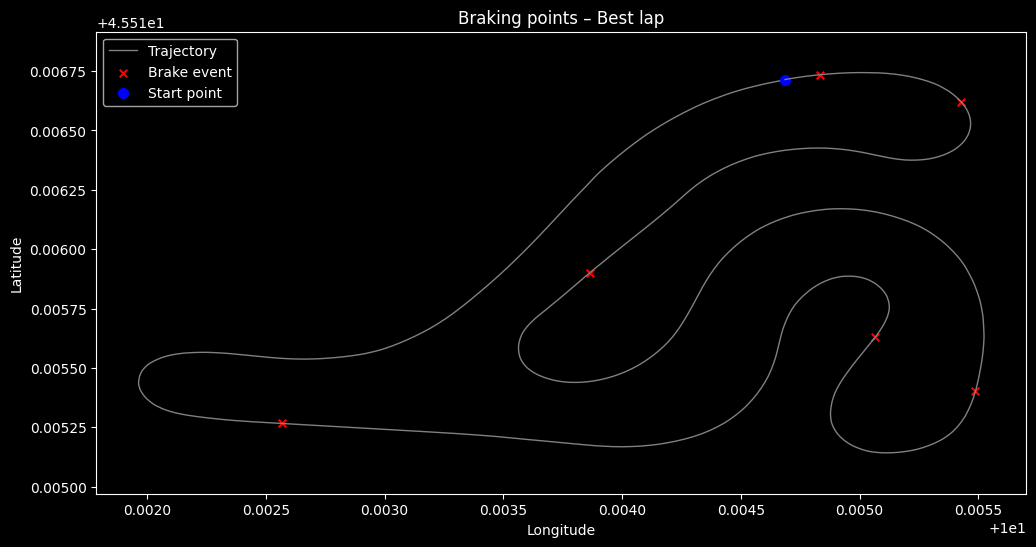

          avg_decel  max_decel  braking_length  entry_speed  min_speed
Brake_id                                                              
1         -1.034867    -1.0571        3.248321     119.1709   116.1471
2         -1.149750    -1.2435        2.997272      72.9707    71.2197
3         -1.519682    -1.7764       14.598353     116.8020    96.2227
4         -1.389557    -1.5664        8.073703     103.1566    92.8604
5         -1.230136    -1.3928       10.892908      88.5324    70.2277
6         -1.386741    -1.7194       37.196144     123.9980    71.5117


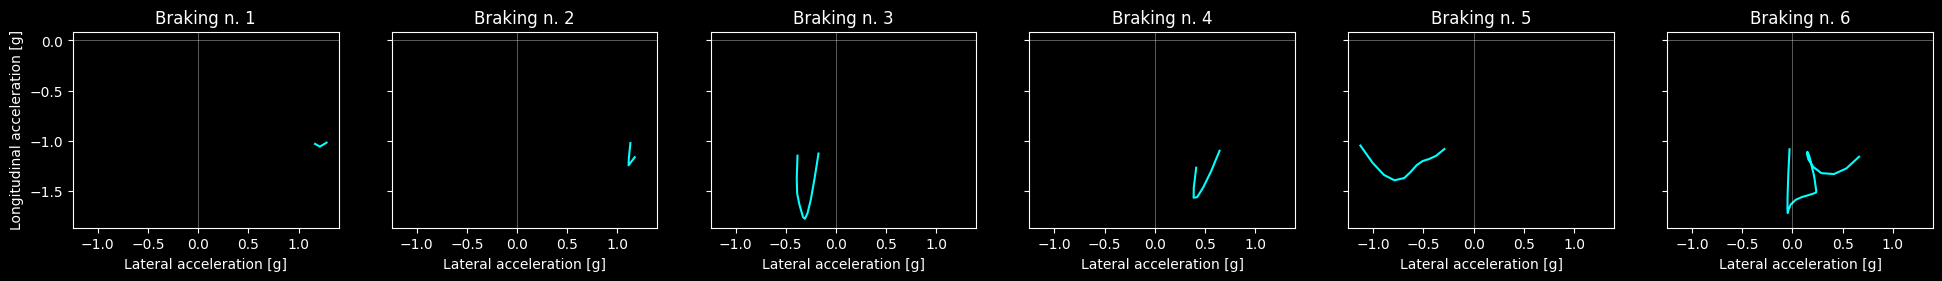

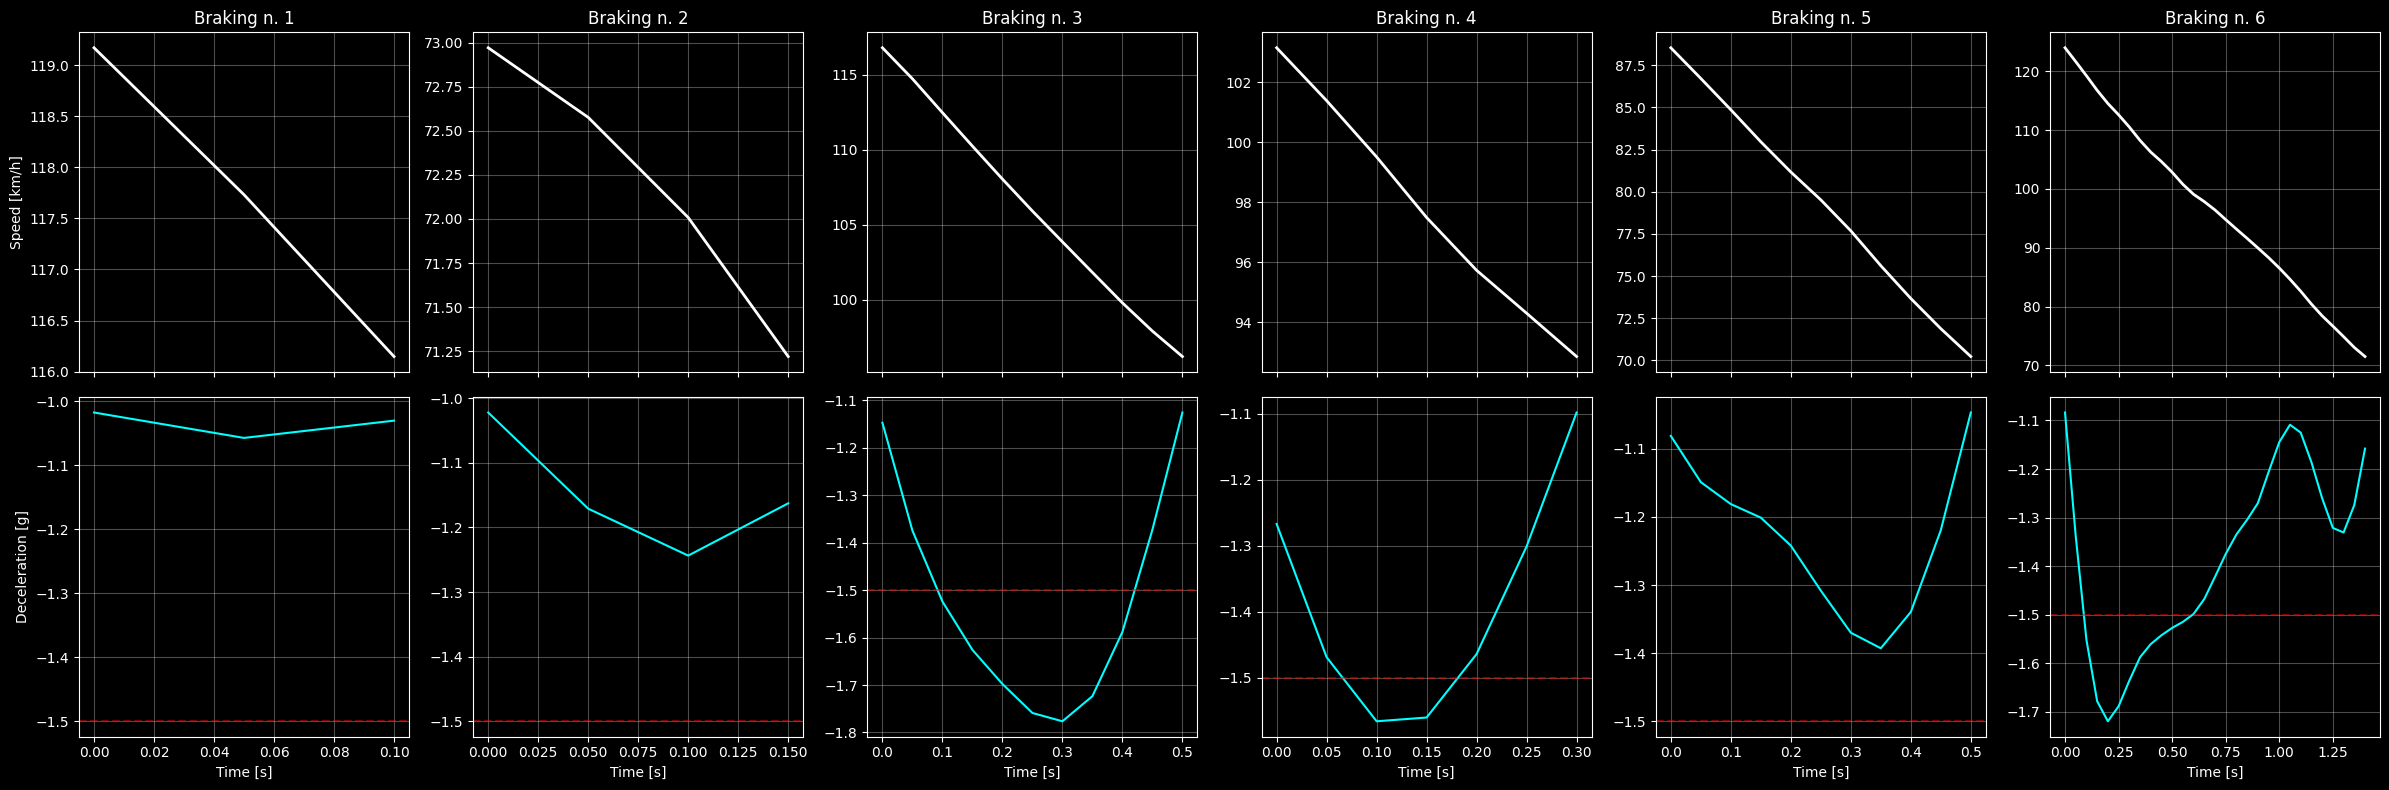

In [11]:
# identify braking zones
braking_zones(best_lap, min_dec = -1)
# plot
braking_plot(best_lap)
braking_kpi = braking_kpi(best_lap)
print(braking_kpi)
braking_analysis(best_lap)



## Traction & Acceleration Analysis

The acceleration phase begins at the **traction point** — the moment the driver
commits to full throttle after the apex. Getting this point right is one of the
biggest differentiators between fast and slow drivers: too early and you run wide,
too late and you leave time on the table.

### Methodology

For each corner, the analysis proceeds in two steps:

**1. Apex detection**
The apex is defined as the point of minimum speed within the corner zone
(identified by lateral acceleration exceeding the threshold). This is the
reference point from which the acceleration phase is measured.

**2. Traction point detection**
The traction point is the first sample after the apex where longitudinal
acceleration exceeds `acc_min = 0.1 g` — the threshold above which the driver
is actively accelerating rather than coasting.

The **pickup distance** is the distance [m] between apex and traction point.
A shorter pickup distance generally means earlier commitment to throttle,
which translates to higher exit speed and better acceleration onto the next
straight.

> ⚠️ Note: a pickup distance of `None` indicates the telemetry session ended
> before a clear acceleration event was detected for that corner.

### Interpreting the results

| Pickup distance | Interpretation |
|---|---|
| < 5 m | Very early traction — aggressive, risk of understeer |
| 5–20 m | Typical range for kart on dry tarmac |
| > 20 m | Late traction — conservative, time loss on exit |

Compare values across corners to identify where you're losing the most time
on corner exit. Focus first on the corners that feed the longest straights.

   Turn_id  pickup_distance
0      1.0         7.796807
1      2.0        44.616540
2      3.0        11.444042
3      4.0         9.919522
4      5.0         4.456321
5      6.0        10.012801
6      7.0        12.925968
7      8.0         5.270900
8      9.0       131.906147
9     10.0              NaN


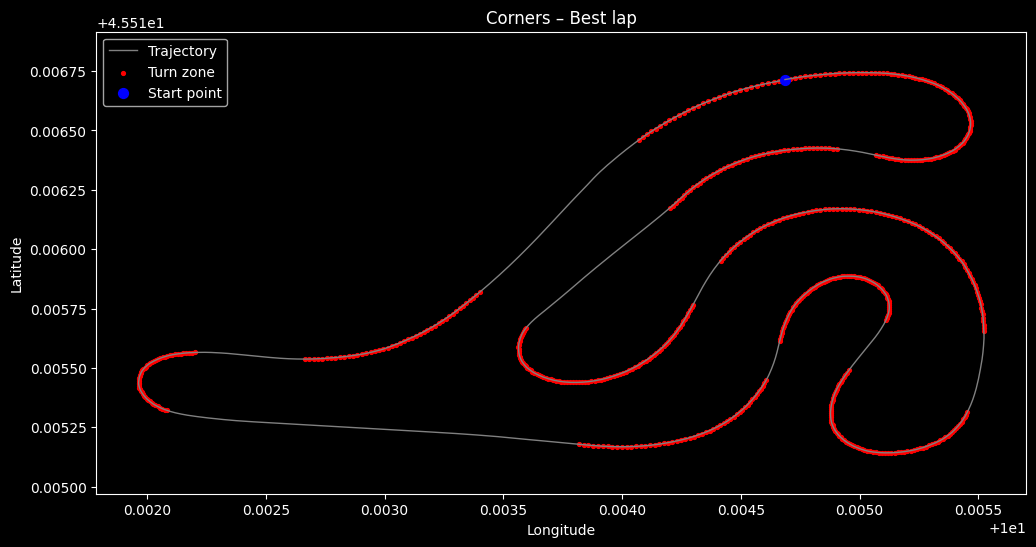

In [12]:

corner_detector(best_lap,acc_threshold=0.8)
# Execution and Output
best_lap, pickup_table = acceleration_pickup_point(best_lap,acc_min = 0.1)
print(pickup_table)
turning_plot(best_lap)